In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = 'data'

In [3]:
df_rallis = pd.read_csv(os.path.join(data_dir, 'rallis_usd.csv'))
df_usd = df_rallis[['date', 'price_usd']].copy()
df_usd['date'] = pd.to_datetime(df_usd['date'])

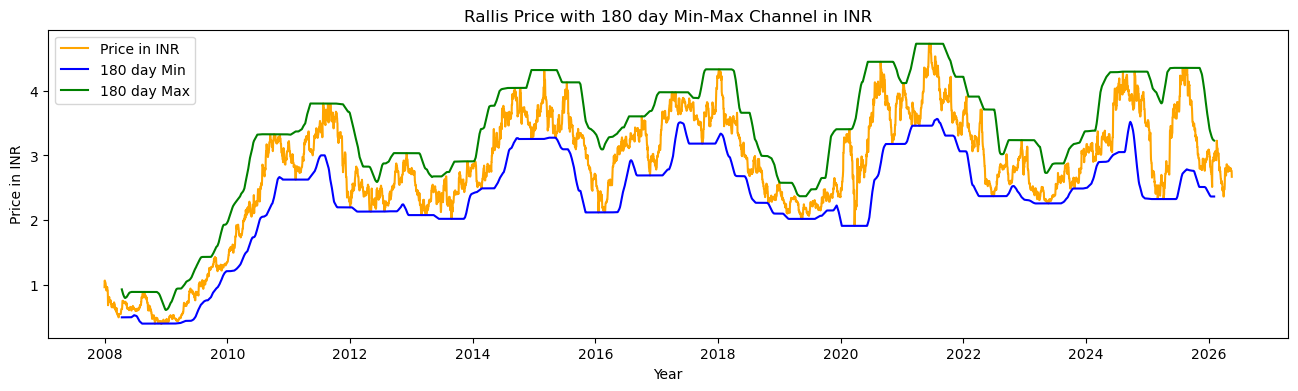

In [4]:
# create a min-max channel for 180 day window
df_usd['price_min'] = df_usd['price_usd'].rolling(window=180).min()
df_usd['price_max'] = df_usd['price_usd'].rolling(window=180).max()
# smooth the min-max channel using moving average
df_usd['price_min'] = df_usd['price_min'].rolling(window=30).mean()
df_usd['price_max'] = df_usd['price_max'].rolling(window=30).mean()
# adjust lag of min-max channel to align with price_usd
# (180 + 30) // 2 = 105
df_usd['price_min'] = df_usd['price_min'].shift(-105)
df_usd['price_max'] = df_usd['price_max'].shift(-105)
plt.figure(figsize=(16, 4))
plt.plot(df_usd['date'], df_usd['price_usd'], label='Price in INR', color='orange')
plt.plot(df_usd['date'], df_usd['price_min'], label='180 day Min', color='blue')
plt.plot(df_usd['date'], df_usd['price_max'], label='180 day Max', color='green')
plt.xlabel('Year')
plt.ylabel('Price in INR')
plt.legend()
plt.title('Rallis Price with 180 day Min-Max Channel in INR')
plt.show()

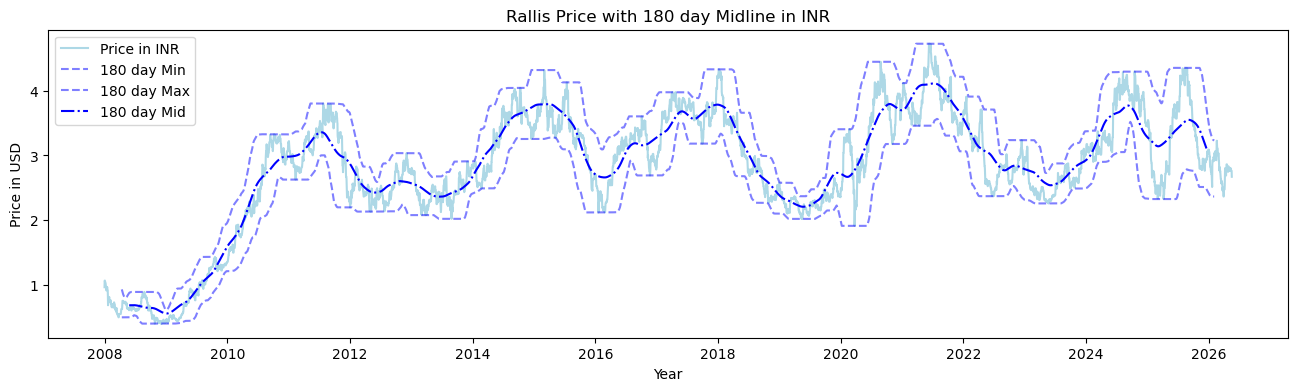

In [30]:
# draw midline of the channel
df_usd['price_mid'] = (df_usd['price_min'] + df_usd['price_max']) / 2
# smooth the midline using moving average
df_usd['price_mid'] = df_usd['price_mid'].rolling(window=90).mean()
# adjust lag of midline to align with price_usd
df_usd['price_mid'] = df_usd['price_mid'].shift(-45)
plt.figure(figsize=(16, 4))
plt.plot(df_usd['date'], df_usd['price_usd'], label='Price in INR', color='lightblue')
plt.plot(df_usd['date'], df_usd['price_min'], label='180 day Min', color='blue', alpha=0.5, linestyle='--')
plt.plot(df_usd['date'], df_usd['price_max'], label='180 day Max', color='blue', alpha=0.5, linestyle='--')
plt.plot(df_usd['date'], df_usd['price_mid'], label='180 day Mid', color='blue', linestyle='-.')
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.legend()
plt.title('Rallis Price with 180 day Midline in INR')
plt.show()

In [41]:
df_focussed = df_usd.loc[df_usd['date'] >= '2010-01-01', ['date', 'price_usd']].copy()
df_focussed

,date,price_usd
731,2010-01-01,1.353674
732,2010-01-02,1.353674
733,2010-01-03,1.353674
734,2010-01-04,1.361279
735,2010-01-05,1.384083
...,...,...
6708,2026-05-14,2.767624
6709,2026-05-15,2.760704
6710,2026-05-16,2.760704
6711,2026-05-17,2.760704


In [42]:
# find max actual price of each crest and min actual price of each trough
from scipy.signal import find_peaks
peaks, _ = find_peaks(df_focussed['price_usd'].dropna(), distance=180, prominence=0.12)
troughs, _ = find_peaks(-df_focussed['price_usd'].dropna(), distance=180, prominence=0.12)
crest_prices = df_focussed['price_usd'].iloc[peaks]
trough_prices = df_focussed['price_usd'].iloc[troughs]
print(f'Max price at crests: {crest_prices.max():.2f}')
print(f'Min price at troughs: {trough_prices.min():.2f}')

Max price at crests: 4.73
Min price at troughs: 1.50
